In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\ML\ML-12 Clustering Resources16936475700.txt")
data

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


In [3]:
import matplotlib.pyplot as plt

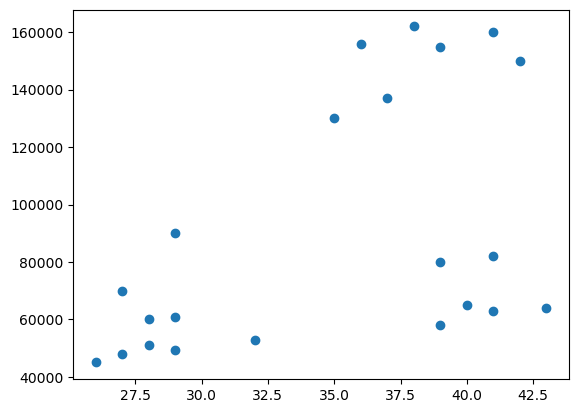

In [4]:
plt.scatter(data["Age"],data["Income($)"])

In [5]:
from sklearn.cluster import KMeans

In [6]:
model = KMeans(3)

In [7]:
model.fit_predict(data)

C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Admin\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Admin\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
a = model.fit_predict(data)
a

array([1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2],
      dtype=int32)

In [10]:
data["group"] = a

In [11]:
data

,Age,Income($),group
0,27,70000,1
1,29,90000,1
2,29,61000,2
3,28,60000,2
4,42,150000,0
5,39,155000,0
6,41,160000,0
7,38,162000,0
8,36,156000,0
9,35,130000,0


In [12]:
model.cluster_centers_

array([[3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04],
       [3.29090909e+01, 5.61363636e+04]])

In [13]:
data.replace([0,2,1],["high","medium","low"])

,Age,Income($),group
0,27,70000,low
1,29,90000,low
2,29,61000,medium
3,28,60000,medium
4,42,150000,high
5,39,155000,high
6,41,160000,high
7,38,162000,high
8,36,156000,high
9,35,130000,high


In [14]:
high = data[data["group"] == 0]
medium = data[data["group"] == 2]
low = data[data["group"] == 1]

In [15]:
model.cluster_centers_

array([[3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04],
       [3.29090909e+01, 5.61363636e+04]])

In [16]:
age_c = model.cluster_centers_[:,0]
income_c = model.cluster_centers_[:,1]

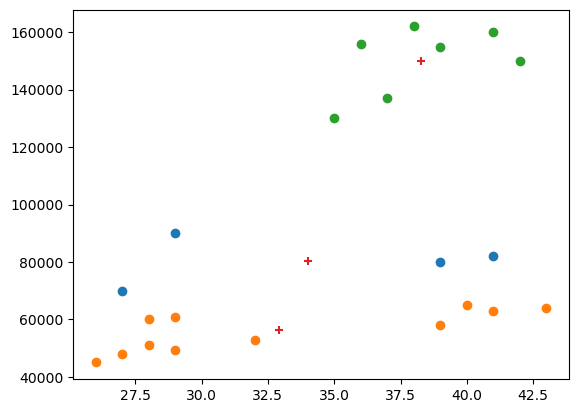

In [17]:
plt.scatter(low["Age"],low["Income($)"])
plt.scatter(medium["Age"],medium["Income($)"])
plt.scatter(high["Age"],high["Income($)"])
plt.scatter(age_c,income_c,marker="+")
plt.show()

In [18]:
from sklearn.metrics import silhouette_score

In [19]:
ypri = model.predict(data[["Age","Income($)"]])
ypri

array([1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2],
      dtype=int32)

In [20]:
silhouette_score(data,ypri)

0.6555650939550239

In [21]:
data = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\ML\ML-12 Clustering Resources16936475700.txt")
data

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000
5,39,155000
6,41,160000
7,38,162000
8,36,156000
9,35,130000


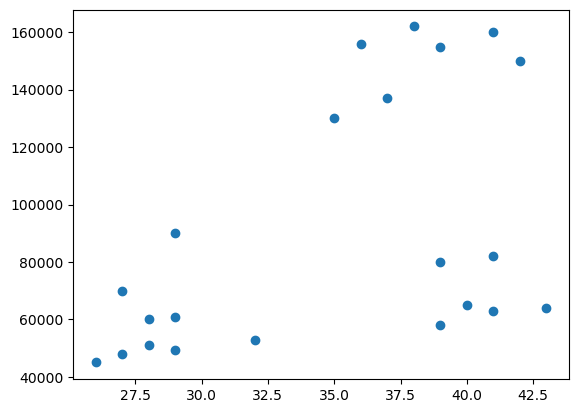

In [22]:
plt.scatter(data["Age"],data["Income($)"])

In [23]:
from sklearn.cluster import AgglomerativeClustering

In [24]:
model = AgglomerativeClustering(3)

In [25]:
cluster = model.fit_predict(data)
cluster

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1])

In [26]:
data["gpcluster"] = cluster

In [27]:
data

,Age,Income($),gpcluster
0,27,70000,1
1,29,90000,2
2,29,61000,1
3,28,60000,1
4,42,150000,0
5,39,155000,0
6,41,160000,0
7,38,162000,0
8,36,156000,0
9,35,130000,0


In [28]:
from scipy.cluster.hierarchy import linkage,dendrogram

In [29]:
merge = linkage(data)

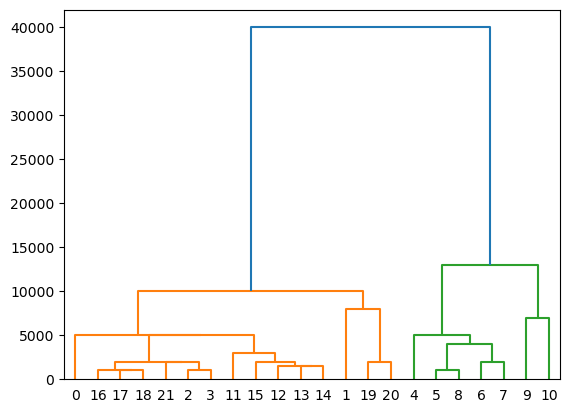

In [30]:
dendrogram(merge,leaf_rotation=360)
plt.show()

In [31]:
silhouette_score(data,cluster)

0.6817458576831205